In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [89]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Any

import json
import random
import time
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import mannwhitneyu
from tqdm import tqdm, trange

warnings.filterwarnings("ignore")

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# =============================================================================
# EXPERIMENT SETTINGS
# =============================================================================

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)

NUM_RUNS = 10
EPISODE_BUDGET = 1500

BASE_SEED_START = 5000

ENV_NAME = "Taxi-v4"

MAX_STEPS = 200
EPSILON = 0.01

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study")

AGENT_PATH = ROOT / "agents" / "dynaq" / "taxi"

RESULTS_DIR = ROOT / "results" / "taxi"
RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [RESULTS_DIR, RAW_DIR, TABLES_DIR, FIGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Agent:", AGENT_PATH)
print("Results:", RESULTS_DIR)

Agent: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/dynaq/taxi
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/taxi


In [90]:
# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(AGENT_PATH / "dynaq_q.npy")

cfg_file = AGENT_PATH / "dynaq_config.json"

AGENT_CFG = (
    json.load(open(cfg_file))
    if cfg_file.exists()
    else {}
)

N_STATES = Q.shape[0]
N_ACTIONS = Q.shape[1]

print("Q-table shape:", Q.shape)

# =============================================================================
# TAXI UTILITIES
# =============================================================================

LANDMARKS = [
    (0, 0),  # R
    (0, 4),  # G
    (4, 0),  # Y
    (4, 3),  # B
]


def decode_taxi(state: int):

    state = int(state)

    d = state % 4
    state //= 4

    p = state % 5
    state //= 5

    c = state % 5
    state //= 5

    r = state

    return r, c, p, d


def encode_taxi(r, c, p, d):

    return int(
        ((r * 5 + c) * 5 + p) * 4 + d
    )


def random_valid_state(rng):

    r = int(rng.integers(0, 5))
    c = int(rng.integers(0, 5))

    p = int(rng.integers(0, 5))
    d = int(rng.integers(0, 4))

    return encode_taxi(r, c, p, d)


def steps_between(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

Q-table shape: (500, 6)


In [91]:
# =============================================================================
# EPISODE EXECUTION
# =============================================================================

def run_episode(
    initial_state,
    seed,
    epsilon=EPSILON,
):

    env = gym.make(ENV_NAME)

    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)

    state = int(initial_state)

    rng = np.random.default_rng(seed)

    total_reward = 0.0
    steps = 0

    done = False

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:

        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        total_reward += reward
        state = int(next_state)

        steps += 1

    elapsed = time.perf_counter() - t0

    env.close()

    return {
        "return": float(total_reward),
        "failure": int(total_reward < 0),
        "steps": int(steps),
        "time": float(elapsed),
    }


# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(results_df, tcp_time=0.0):

    failures = results_df["failure"].values.astype(int)
    times = results_df["time"].values.astype(float)

    n = len(failures)

    total_failures = int(np.sum(failures))

    FR = total_failures / n if n else np.nan

    if total_failures:

        first_idx = np.where(failures == 1)[0][0]

        TTF_tests = first_idx + 1

        TTF_time = np.sum(times[: first_idx + 1])

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures:

        positions = np.where(failures == 1)[0] + 1

        APFD = (
            1
            - np.sum(positions) / (n * total_failures)
            + 1 / (2 * n)
        )

        cumulative_time = np.cumsum(times)

        fail_times = cumulative_time[
            np.where(failures == 1)[0]
        ]

        total_time = cumulative_time[-1]

        APFD_time = (
            1
            - np.sum(fail_times) /
              (total_time * total_failures)
            + 1 / (2 * total_time)
        )

    else:

        APFD = np.nan
        APFD_time = np.nan

    return {
        "FR": FR,
        "TTF_tests": TTF_tests,
        "TTF_time": TTF_time,
        "APFD": APFD,
        "APFD_time": APFD_time,
        "TCP_time": tcp_time,
        "Per_test_overhead": tcp_time / n,
    }

In [92]:
# =============================================================================
# TCP SIGNALS
# =============================================================================

def softmax(q):

    q = q - np.max(q)

    e = np.exp(q)

    return e / np.sum(e)


def extract_tcp_signals(test):

    s = int(test["initial_state"])

    q = Q[s]

    probs = softmax(q)

    entropy = float(
        -np.sum(
            probs * np.log(probs + 1e-12)
        )
    )

    confidence = float(np.max(probs))

    q_sorted = np.sort(q)[::-1]

    margin = (
        float(q_sorted[0] - q_sorted[1])
        if len(q_sorted) >= 2
        else 0.0
    )

    q_variance = float(np.var(q))

    value_return_gap = abs(
        float(np.max(q))
        - float(test["return"])
    )

    return {
        "Entropy": entropy,
        "Confidence": confidence,
        "Margin": margin,
        "QVariance": q_variance,
        "ValueReturnGap": value_return_gap,
    }


def attach_signals(pool):

    for t in pool:
        t.update(
            extract_tcp_signals(t)
        )

    counts = Counter(
        int(t["initial_state"])
        for t in pool
    )

    for t in pool:

        s = int(t["initial_state"])

        t["StateNovelty"] = 1.0 / counts[s]

    return pool


# =============================================================================
# TCP ORDERINGS
# =============================================================================

def tcp_fifo(pool):
    return sorted(pool, key=lambda x: x["episode_id"])


def tcp_random(pool, seed):

    pool = pool.copy()

    rng = np.random.default_rng(seed)

    rng.shuffle(pool)

    return pool


def tcp_entropy(pool):
    return sorted(pool, key=lambda x: x["Entropy"], reverse=True)


def tcp_margin(pool):
    return sorted(pool, key=lambda x: x["Margin"])


def tcp_confidence(pool):
    return sorted(pool, key=lambda x: x["Confidence"])


def tcp_value_return_gap(pool):
    return sorted(pool, key=lambda x: x["ValueReturnGap"], reverse=True)


def tcp_q_variance(pool):
    return sorted(pool, key=lambda x: x["QVariance"], reverse=True)


def tcp_state_novelty(pool):
    return sorted(pool, key=lambda x: x["StateNovelty"], reverse=True)


TCP_REGISTRY = {
    "FIFO": tcp_fifo,
    "Random": tcp_random,
    "Entropy": tcp_entropy,
    "Margin": tcp_margin,
    "Confidence": tcp_confidence,
    "ValueReturnGap": tcp_value_return_gap,
    "QVariance": tcp_q_variance,
    "StateNovelty": tcp_state_novelty,
}

In [93]:
# =============================================================================
# PHASE 1 — TCP-ONLY RANDOM POOL EXPERIMENT
# =============================================================================

def generate_random_pool(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
):
    """
    Generate a fixed random pool.

    Each episode is executed once.
    TCP methods only reorder the same pool.
    """

    rng = np.random.default_rng(base_seed)

    pool = []

    for episode_id in range(budget):

        seed = int(base_seed + episode_id)

        state = random_valid_state(rng)

        result = run_episode(
            initial_state=state,
            seed=seed,
        )

        pool.append({
            "episode_id": episode_id,
            "seed": seed,
            "initial_state": int(state),

            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    return pool


def apply_tcp(
    pool,
    tcp_name,
    run_seed,
):
    """
    Apply one TCP method.
    """

    start = time.perf_counter()

    if tcp_name == "Random":
        ordered = TCP_REGISTRY[tcp_name](
            pool,
            seed=run_seed,
        )
    else:
        ordered = TCP_REGISTRY[tcp_name](pool)

    tcp_time = time.perf_counter() - start

    return ordered, tcp_time

def evaluate_phase1_pool(
    ordered_pool,
    tcp_time,
):

    df = pd.DataFrame({
        "failure": [t["failure"] for t in ordered_pool],
        "time": [t["time"] for t in ordered_pool],
    })

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return metrics


def run_phase1_single_run(
    run_id: int,
    base_seed: int,
):
    """
    One Phase-1 repetition.
    """

    print(
        f"\nPhase 1 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    pool = generate_random_pool(
        base_seed=base_seed,
        budget=EPISODE_BUDGET,
    )

    pool = attach_signals(pool)

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = apply_tcp(
            pool,
            tcp_name,
            base_seed,
        )

        metrics = evaluate_phase1_pool(
            ordered_pool,
            tcp_time,
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):
    """
    Phase 1 experiment.

    Random pool only.
    No RL testing frameworks.
    """

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(results):
    """
    Aggregate statistics.
    """

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase1_aggregate.csv",
        index=False,
    )

    return agg


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6, 3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(list(TCP_REGISTRY.keys()))
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("Phase 1 — TCP-only")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    plt.savefig(
        FIGS_DIR / "phase1_apfd.pdf",
        bbox_inches="tight",
    )

    plt.show()

In [94]:
def _bd_taxi(state: int) -> Tuple[int, int]:
    """Behaviour descriptor: (steps to pickup, steps to dropoff)."""
    r, c, p, d = decode_taxi(state)
    taxi   = (r, c)
    pickup = 0 if p == 4 else steps_between(taxi, LANDMARKS[p])
    drop   = steps_between(taxi, LANDMARKS[d])
    return (int(pickup), int(drop))


def _bd_cell(bd: Tuple[int, int]) -> Tuple[int, int]:
    """Discretise BD into archive cell"""
    return (min(8, bd[0]), min(8, bd[1]))

# ==============================================================================
# FRAMEWORK: INDAGO
# ==============================================================================
#
# Literature definition (Indago — Perez et al.):
#   1. Draw a large candidate pool.
#   2. Train a failure-predicting classifier on a labelled subset.
#   3. Score all candidates; select the top-K most risky as the test suite.
#
# TCP is applied AFTER selection.
from sklearn.ensemble import RandomForestClassifier

def _indago_features(state: int) -> list:
    r, c, p, d = decode_taxi(state)
    taxi = (r, c)

    goal = LANDMARKS[p] if p != 4 else LANDMARKS[d]

    dist_goal = steps_between(taxi, goal)
    dist_all  = [steps_between(taxi, lm) for lm in LANDMARKS]

    q_row = Q[state]
    q_max = float(np.max(q_row))
    q_var = float(np.var(q_row))

    # gap (top1 - top2)
    if len(q_row) >= 2:
        sorted_q = np.sort(q_row)
        q_gap = float(sorted_q[-1] - sorted_q[-2])
    else:
        q_gap = 0.0

    probs = softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    return [
        r, c, p, d,
        dist_goal,
        min(dist_all),
        q_max,
        q_var,
        q_gap,
        entropy
    ]
def _indago_label(state: int, seed: int) -> int:
    """
    Label a state as failure (1) or success (0)
    using the ground-truth oracle.
    """
    res = run_episode(
        initial_state=state,
        seed=seed,
        epsilon=0.0,
    )
    return int(res["failure"])

def generate_tests_indago(
    base_seed,
    budget=EPISODE_BUDGET,
    pool_size=6000,
    train_size=1200,
):

    env = gym.make(ENV_NAME)
    pool = []
    for i in range(pool_size):
        s, _ = env.reset(seed=int(base_seed + i))
        pool.append({
            "episode_id": i,
            "seed": int(base_seed + i),
            "initial_state": int(s),
        })
    env.close()

    # --- TRUE INDAGO: label subset ---
    X_train, y_train = [], []
    for t in pool[:train_size]:
        s = int(t["initial_state"])
        lbl = _indago_label(s, t["seed"])
        X_train.append(_indago_features(s))
        y_train.append(lbl)
    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=base_seed
    )

    clf.fit(X_train, y_train)

    # --- predict failure probability ---
    scores = []

    for t in pool:
        s = int(t["initial_state"])
        proba = clf.predict_proba([_indago_features(s)])[0]

        if len(proba) == 1:
            prob = 0.0 if clf.classes_[0] == 0 else 1.0
        else:
            prob = proba[1]

        scores.append(prob)

    sel_idx = np.argsort(-np.array(scores))[:budget]

    test_pool = [
        {**pool[int(i)], "episode_id": rank}
        for rank, i in enumerate(sel_idx)
    ]

    return test_pool
# ==============================================================================
#FRAMEWORK: STARLA
# ==============================================================================
#
# Literature definition (STARLA — Acharya et al.):
#   Genetic-algorithm search over initial states, guided by a risk proxy
#   (Q-gap + distance-to-goal).  Failure-eliciting seeds are kept as parents;
#   offspring are mutated variants.

def _risk_proxy(state: int) -> float:
    """
    Higher value → state is riskier for the agent.
    Uses Q-gap (inverse of decisiveness) + Manhattan distance to goal.
    """
    q_row          = Q[int(state)]
    sorted_q       = np.sort(q_row)
    q_gap          = float(sorted_q[-1] - sorted_q[-2]) if N_ACTIONS >= 2 else 0.0
    r, c, p, d     = decode_taxi(state)
    taxi            = (r, c)
    goal            = LANDMARKS[p] if p != 4 else LANDMARKS[d]
    dist            = steps_between(taxi, goal)
    return float(1.0 / (q_gap + 1e-6)) + dist


def _mutate_state_starla(state: int, rng: np.random.Generator) -> int:
    """
    Mutate a Taxi state: perturb taxi position or swap passenger/dest with
    small probability while keeping the state valid.
    """
    r, c, p, d = decode_taxi(state)

    move = rng.integers(0, 4)
    if   move == 0: r = int(np.clip(r + rng.choice([-1, 1]), 0, 4))
    elif move == 1: c = int(np.clip(c + rng.choice([-1, 1]), 0, 4))
    elif move == 2: p = int(rng.integers(0, 5))    # 0-4 (4 = in taxi)
    else:           d = int(rng.integers(0, 4))    # destination landmark

    return encode_taxi(r, c, p, d)


def _eval_state_fast(state: int, seed: int) -> Tuple[float, int, int]:
    res = run_episode(
        initial_state=state,
        seed=seed,
        epsilon=0.0,
    )

    return res["return"], res["steps"], res["failure"]


def generate_tests_starla(
    base_seed : int,
    budget    : int = EPISODE_BUDGET,
    pop_size  : int = 100,
) -> List[Dict]:

    rng  = np.random.default_rng(base_seed)
    gens = budget // pop_size

    # ── Initial population ──────────────────────────────────────────────────
    env = gym.make(ENV_NAME)
    pop = []
    for i in range(pop_size):
        s, _ = env.reset(seed=int(base_seed + i))
        pop.append(int(s))
    env.close()

    pool: List[Dict] = []

    for _gen in trange(gens, desc="STARLA: evolving", leave=False):
        scored = []
        for state in pop:
            seed_ep   = int(base_seed + len(pool))
            ret, stp, fail = _eval_state_fast(state, seed_ep)
            bd = _bd_taxi(state)
            novelty = 1.0 / (1 + sum(bd))
            fitness = 10.0 * fail + _risk_proxy(state) + novelty - 0.1 * ret
            pool.append({
                "episode_id"   : len(pool),
                "seed"         : seed_ep,
                "initial_state": int(state),
            })
            scored.append((fitness, state))

            if len(pool) >= budget:
                break

        if len(pool) >= budget:
            break

        # ── Selection ────────────────────────────────────────────────────────
        scored.sort(key=lambda x: x[0], reverse=True)
        n_parents = max(1, pop_size // 2)
        parents   = [s for _, s in scored[:n_parents]]

        # ── Offspring ────────────────────────────────────────────────────────
        offspring: List[int] = []
        while len(offspring) < pop_size - n_parents:
            parent   = int(rng.choice(parents))
            child    = _mutate_state_starla(parent, rng)
            offspring.append(child)

        pop = parents + offspring

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: QD-TESTING
# ==============================================================================
#
# Literature definition (QD-Testing — Castellano et al.):
#   Quality-Diversity search: maintain an archive of (behaviour_descriptor → best_seed).
#   Behaviour descriptor: (steps_to_pickup, steps_to_dropoff).
#   Fitness: (failure_flag, −steps)  — lexicographic maximisation.
#   Generate initial random seeds, then mutate archive elites.



def generate_tests_qd(
    base_seed     : int,
    budget        : int = EPISODE_BUDGET,
    init_seeds    : int = 200,
) -> List[Dict]:

    rng     = np.random.default_rng(base_seed)
    archive : Dict[Tuple, Dict] = {}
    pool    : List[Dict]        = []

    def _score(fail: int, steps: int) -> Tuple[int, int]:
        return (int(fail), -int(steps))

    def _try_add(state: int, seed: int):
        ret, stp, fail = _eval_state_fast(state, seed)
        bd   = _bd_taxi(state)
        cell = _bd_cell(bd)
        sc   = _score(fail, stp)
        if (cell not in archive) or (sc > archive[cell]["score"]):
            archive[cell] = {
                "state": state,
                "seed" : seed,
                "score": sc,
            }
        pool.append({
            "episode_id"   : len(pool),
            "seed"         : int(seed),
            "initial_state": int(state),
        })

    # ── Initial random seeds ─────────────────────────────────────────────────
    for i in trange(init_seeds, desc="QD-Testing: init", leave=False):
        state = random_valid_state(rng)
        _try_add(state, int(base_seed + i))

    # ── Mutation loop ────────────────────────────────────────────────────────
    while len(pool) < budget:
        if archive:
            elite = random.choice(list(archive.values()))
            state = _mutate_state_starla(elite["state"], rng)   # same mutation op
        else:
            state = random_valid_state(rng)

        seed_ep = int(base_seed + len(pool))
        _try_add(state, seed_ep)

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: RLMUTATION
# ==============================================================================
#
# Literature definition (RLMutation — Tappler et al.):
#   Apply environment mutants (wrappers that alter dynamics/rewards) and
#   collect episodes that behave differently from the nominal agent.
#   Failure = nominal oracle on the ORIGINAL environment.
#
# Four mutation operators are used (each gets budget/4 episodes):
#   RN  — reward noise on positive rewards
#   M   — mangled observations (random replay from history)
#   R   — repeated observation (repeat previous obs with probability p)
#   WA  — worst-action perturbation (replace greedy with argmin-Q)

class _RN_RewardNoise(gym.Wrapper):
    """Corruption: add Gaussian noise to positive rewards."""
    def __init__(self, env, p: float = 0.2, sigma: float = 0.5):
        super().__init__(env)
        self.p     = p
        self.sigma = sigma

    def step(self, a):
        s2, r, term, trunc, info = self.env.step(a)
        if r > 0 and np.random.rand() < self.p:
            r = float(r + np.random.normal(0.0, self.sigma))
        return s2, r, term, trunc, info


class _M_MangledObs(gym.Wrapper):
    """Corruption: randomly replay a past observation."""
    def __init__(self, env, p: float = 0.2):
        super().__init__(env)
        self.p   = p
        self.buf : List = []

    def reset(self, **kw):
        self.buf.clear()
        return self.env.reset(**kw)

    def step(self, a):
        out = self.env.step(a)
        self.buf.append(out)
        if self.p > 0 and self.buf and np.random.rand() < self.p:
            out = random.choice(self.buf)
        return out


class _R_RepeatObs(gym.Wrapper):
    """Corruption: repeat previous observation with probability p."""
    def __init__(self, env, p: float = 0.2):
        super().__init__(env)
        self.p    = p
        self.prev = None

    def reset(self, **kw):
        self.prev = None
        return self.env.reset(**kw)

    def step(self, a):
        out = self.env.step(a)
        if self.prev is not None and np.random.rand() < self.p:
            out = self.prev
        self.prev = out
        return out


def _run_episode_on_wrapped(env, seed: int, initial_state: int) -> Dict:
    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)
    state           = int(initial_state)
    total           = 0.0
    steps           = 0
    done            = False
    t0              = time.perf_counter()

    while not done and steps < MAX_STEPS:
        action = int(np.argmax(Q[state]))
        out    = env.step(action)
        if len(out) == 5:
            next_s, r, term, trunc, _ = out
            done = term or trunc
        else:
            next_s, r, done, _ = out

        total += r
        state  = int(next_s)
        steps += 1

    return {
        "return" : float(total),
        "failure": int(total < 0),
        "steps"  : int(steps),
        "time"   : float(time.perf_counter() - t0),
    }


def generate_tests_rlmutation(base_seed: int, budget: int = EPISODE_BUDGET) -> List[Dict]:
    rng         = np.random.default_rng(base_seed)
    share       = budget // 4
    pool        : List[Dict] = []
    mutant_tags = ["RN", "M", "R", "WA"]

    env_base = gym.make(ENV_NAME)
    init_states = []
    for i in range(budget):
        s, _ = env_base.reset(seed=int(base_seed + i))
        init_states.append(int(s))
    env_base.close()

    mutant_factories = [
        lambda: _RN_RewardNoise(gym.make(ENV_NAME)),
        lambda: _M_MangledObs(gym.make(ENV_NAME)),
        lambda: _R_RepeatObs(gym.make(ENV_NAME)),
        lambda: gym.make(ENV_NAME),
    ]

    for k, tag in enumerate(mutant_tags):
        states_k = init_states[k * share : (k + 1) * share]

        for i, state in enumerate(
            tqdm(states_k, desc=f"RLMutation [{tag}]", leave=False)
        ):
            seed_ep = int(base_seed + k * share + i)

            if tag == "WA":
                env_m = gym.make(ENV_NAME)
                env_m.reset(seed=seed_ep)
                env_m.unwrapped.s = state
                s     = state
                total = 0.0
                steps = 0
                done  = False
                t0    = time.perf_counter()
                while not done and steps < MAX_STEPS:
                    a = int(np.argmin(Q[s]))
                    out = env_m.step(a)
                    if len(out) == 5:
                        ns, r, term, trunc, _ = out; done = term or trunc
                    else:
                        ns, r, done, _ = out
                    total += r; s = int(ns); steps += 1
                elapsed = time.perf_counter() - t0
                fail    = int(total < 0)
                env_m.close()
            else:
                env_m   = mutant_factories[k]()
                res     = _run_episode_on_wrapped(env_m, seed_ep, state)
                fail    = res["failure"]
                elapsed = res["time"]
                env_m.close()

            pool.append({
                "episode_id"   : len(pool),
                "seed"         : seed_ep,
                "initial_state": int(state),
                "mutant"       : tag,
                "mutant_failure": int(fail),
            })
    rng = np.random.default_rng(base_seed + 12345)
    rng.shuffle(pool)

    for i, t in enumerate(pool):
        t["episode_id"] = i
    return pool[:budget]

def evaluate_ordered_pool(
    ordered_pool,
    Q,
    tcp_time,
):

    rows = []

    for test in ordered_pool:

        result = run_episode(
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            epsilon=EPSILON,
        )

        rows.append(result)

    df = pd.DataFrame(rows)

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return df, metrics

def evaluate_ordered_pool_rlmutation(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        state = int(test["initial_state"])
        seed  = int(test["seed"])
        tag   = test.get("mutant", "NONE")

        # Execute according to mutant type
        if tag == "WA":
            env = gym.make(ENV_NAME)
            env.reset(seed=seed)
            env.unwrapped.s = state

            s = state
            total = 0.0
            steps = 0
            done = False
            t0 = time.perf_counter()

            while not done and steps < MAX_STEPS:
                a = int(np.argmin(Q[s]))
                out = env.step(a)
                if len(out) == 5:
                    ns, r, term, trunc, _ = out
                    done = term or trunc
                else:
                    ns, r, done, _ = out

                total += r
                s = int(ns)
                steps += 1

            env.close()
            clean_res = run_episode(
                initial_state=state,
                seed=seed,
                epsilon=0.0,
            )
            result = {
                "return": clean_res["return"],
                "failure": clean_res["failure"],
                "steps": clean_res["steps"],
                "time": clean_res["time"],
            }
        else:
            if tag == "RN":
                env = _RN_RewardNoise(gym.make(ENV_NAME))
            elif tag == "M":
                env = _M_MangledObs(gym.make(ENV_NAME))
            elif tag == "R":
                env = _R_RepeatObs(gym.make(ENV_NAME))
            else:
                env = gym.make(ENV_NAME)

            result = _run_episode_on_wrapped(env, seed, state)
            env.close()

        rows.append(result)

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics

# ==============================================================================
# FRAMEWORK: MDPFUZZ
# ==============================================================================
#
# Literature definition (MDPFuzz — Qi et al.):
#   Coverage-guided fuzzing of the MDP input space.
#   Seed: (initial_state).  Mutation: random perturbation of all state fields.
#   Corpus: seeds that trigger failures; coverage: unique BD cells visited.

def _mutate_state_mdpfuzz(state: int, rng: np.random.Generator) -> int:
    r, c, p, d = decode_taxi(state)

    # Taxi position: random step in any direction
    dr = int(rng.choice([-1, 0, 1]))
    dc = int(rng.choice([-1, 0, 1]))
    r  = int(np.clip(r + dr, 0, 4))
    c  = int(np.clip(c + dc, 0, 4))

    # Passenger: resample with 30% probability
    if rng.random() < 0.30:
        p = int(rng.integers(0, 5))   # 0-4

    # Destination: resample with 30% probability
    if rng.random() < 0.30:
        d = int(rng.integers(0, 4))   # 0-3

    # Ensure passenger ≠ destination when passenger is at a landmark
    if p < 4 and p == d:
        d = int((d + 1) % 4)

    return encode_taxi(r, c, p, d)


def generate_tests_mdpfuzz(
    base_seed : int,
    budget    : int = EPISODE_BUDGET,
    init_size : int = 300,
) -> List[Dict]:

    rng      = np.random.default_rng(base_seed)
    corpus   : List[int] = []
    coverage : set        = set()
    pool     : List[Dict] = []

    env = gym.make(ENV_NAME)

    # ── Initial corpus ───────────────────────────────────────────────────────
    for i in trange(init_size, desc="MDPFuzz: init corpus", leave=False):
        s, _ = env.reset(seed=int(base_seed + i))
        state = int(s)
        seed_ep = int(base_seed + i)
        ret, stp, fail = _eval_state_fast(state, seed_ep)
        cell = _bd_cell(_bd_taxi(state))

        if fail or cell not in coverage:
            corpus.append(state)
            coverage.add(cell)

        pool.append({
            "episode_id"   : len(pool),
            "seed"         : seed_ep,
            "initial_state": state,
        })

    env.close()
    if not corpus:
        corpus = [pool[i]["initial_state"] for i in range(min(50, len(pool)))]

    # ── Fuzzing loop ─────────────────────────────────────────────────────────
    while len(pool) < budget:
        parent  = int(rng.choice(corpus))
        state   = _mutate_state_mdpfuzz(parent, rng)
        seed_ep = int(base_seed + len(pool))
        ret, stp, fail = _eval_state_fast(state, seed_ep)
        cell = _bd_cell(_bd_taxi(state))

        if fail or cell not in coverage:
            corpus.append(state)
            coverage.add(cell)

        pool.append({
            "episode_id"   : len(pool),
            "seed"         : seed_ep,
            "initial_state": state,
        })

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: NR-RL
# ==============================================================================
#
# Literature definition (NR-RL — Nakamura et al.):
#   Natural Robustness testing: perturb agent actions at execution time.
#   Test generation = sample clean initial states.
#   TCP ranks by Q-table signals on the clean initial state.
#   Perturbation (worst-action injection at rate p_perturb) is applied
#   ONLY during the evaluation phase.
#

NR_RL_P_PERTURB = 0.30   # probability of replacing greedy with worst-action
NR_RL_Q_GAP_GATE = 0.05  # only perturb when Q-gap is below this threshold


def _qgap(state: int) -> float:
    q     = Q[int(state)]
    q_s   = np.sort(q)
    return float(q_s[-1] - q_s[-2]) if N_ACTIONS >= 2 else 0.0


def generate_tests_nrrl(base_seed: int, budget: int = EPISODE_BUDGET) -> List[Dict]:
    env  = gym.make(ENV_NAME)
    pool = []
    for i in range(budget):
        seed     = int(base_seed + i)
        s, _     = env.reset(seed=seed)
        pool.append({
            "episode_id"   : i,
            "seed"         : seed,
            "initial_state": int(s),
        })
    env.close()
    return pool

def run_episode_nrrl(
    Q,
    initial_state,
    seed,
    p_perturb=NR_RL_P_PERTURB,
    q_gap_gate=NR_RL_Q_GAP_GATE,
    max_steps=MAX_STEPS,
):
    env = gym.make(ENV_NAME)
    env.reset(seed=int(seed))
    env.unwrapped.s = int(initial_state)

    state = int(initial_state)
    rng = np.random.default_rng(seed)

    total = 0.0
    steps = 0
    done = False
    t0 = time.perf_counter()

    while not done and steps < max_steps:

        gap = _qgap(state)

        if gap < q_gap_gate and rng.random() < p_perturb:
            action = int(np.argmin(Q[state]))
        else:
            action = int(np.argmax(Q[state]))

        out = env.step(action)
        if len(out) == 5:
            ns, r, term, trunc, _ = out
            done = term or trunc
        else:
            ns, r, done, _ = out

        total += r
        state = int(ns)
        steps += 1

    env.close()

    return {
        "return": float(total),
        "failure": int(total < 0),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }

def evaluate_ordered_pool_nrrl(
    ordered_pool : List[Dict],
    Q            : np.ndarray,
    tcp_time     : float,
) -> Tuple[pd.DataFrame, Dict]:
    rows = []
    for test in ordered_pool:
        result = run_episode_nrrl(
            Q,
            initial_state = int(test["initial_state"]),
            seed          = int(test["seed"]),
        )
        rows.append(result)
    df      = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics

# ==============================================================================
# FRAMEWORK REGISTRY
# ==============================================================================
FRAMEWORK_REGISTRY: Dict[str, Dict] = {
    "Indago"     : {"gen": generate_tests_indago,    "eval": evaluate_ordered_pool},
    "STARLA"     : {"gen": generate_tests_starla,    "eval": evaluate_ordered_pool},
    "QD-Testing" : {"gen": generate_tests_qd,        "eval": evaluate_ordered_pool},
    "RLMutation" : {"gen": generate_tests_rlmutation, "eval":evaluate_ordered_pool_rlmutation},
    "MDPFuzz"    : {"gen": generate_tests_mdpfuzz,   "eval": evaluate_ordered_pool},
    "NR-RL"      : {"gen": generate_tests_nrrl,      "eval": evaluate_ordered_pool_nrrl},
}


In [95]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, framework in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{framework_name}] "
            f"Generating test pool..."
        )

        t0 = time.perf_counter()

        test_pool = framework["gen"](
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
    )


        for test in test_pool:

            result = run_episode(
                initial_state=int(test["initial_state"]),
                seed=int(test["seed"]),
            )

            test["return"] = result["return"]

        test_pool = attach_signals(test_pool)

        generation_time = (
            time.perf_counter() - t0
        )

        for i, test in enumerate(test_pool):

            if "episode_id" not in test:
                test["episode_id"] = i

        eval_fn = framework["eval"]

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = apply_tcp(
                test_pool,
                tcp_name,
                base_seed,
            )

            df, metrics = eval_fn(
                ordered_pool,
                Q,
                tcp_time,
            )

            row = {
                "run_id": run_id,
                "framework": framework_name,
                "tcp": tcp_name,
                "generation_time": generation_time,
            }

            row.update(metrics)

            rows.append(row)

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase2_results.csv",
        index=False,
    )

    return results


# =============================================================================
# PHASE 2 AGGREGATION
# =============================================================================

def summarize_phase2(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby(
            ["framework", "tcp"]
        )[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase2_aggregate.csv",
        index=False,
    )

    return agg


# =============================================================================
# PHASE 2 STATISTICAL TESTS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            values = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(values) < 2:
                continue

            stat, p = mannwhitneyu(
                values,
                fifo,
                alternative="two-sided",
            )

            d = cliffs_delta(
                values,
                fifo,
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta": d,
            })

    stats = pd.DataFrame(rows)

    stats.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stats

In [96]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta": cliffs_delta(
                vals,
                fifo,
            ),
        })

    stats = pd.DataFrame(rows)

    stats.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stats


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta": cliffs_delta(
                    vals,
                    fifo,
                ),
            })

    stats = pd.DataFrame(rows)

    stats.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stats

In [97]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================
TCP_COLOR_MAP = {
    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",
    "Entropy": "#1F77B4",
    "Margin": "#FF7F0E",
    "Confidence": "#2CA02C",
    "ValueReturnGap": "#9467BD",
    "QVariance": "#8C564B",
    "StateNovelty": "#A6CEE3",
}

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Margin",
    "Confidence",
    "ValueReturnGap",
    "QVariance",
    "StateNovelty",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("Phase 1 — TCP-only")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

TAXI TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)
FIFO              APFD=0.5107
Random            APFD=0.5023
Entropy           APFD=0.8743
Margin            APFD=0.7318
Confidence        APFD=0.8764
ValueReturnGap    APFD=0.8970
QVariance         APFD=0.1358
StateNovelty      APFD=0.5446

Phase 1 | Run 2 (seed=15000)
FIFO              APFD=0.5127
Random            APFD=0.5157
Entropy           APFD=0.8595
Margin            APFD=0.7188
Confidence        APFD=0.8594
ValueReturnGap    APFD=0.8905
QVariance         APFD=0.1444
StateNovelty      APFD=0.5312

Phase 1 | Run 3 (seed=25000)
FIFO              APFD=0.4829
Random            APFD=0.5003
Entropy           APFD=0.8534
Margin            APFD=0.7060
Confidence        APFD=0.8541
ValueReturnGap    APFD=0.8823
QVariance         APFD=0.1557
StateNovelty      APFD=0.4604

Phase 1 | Run 4 (seed=35000)
FIFO              APFD=0.5388
Random            APFD=0.5121
Entropy           APFD=0.8667
Margin            APFD=0.7319


FIFO              APFD=0.3900
Random            APFD=0.4997
Entropy           APFD=0.6873
Margin            APFD=0.4881
Confidence        APFD=0.6872
ValueReturnGap    APFD=0.6913
QVariance         APFD=0.3129
StateNovelty      APFD=0.3391

[QD-Testing] Generating test pool...


FIFO              APFD=0.5201
Random            APFD=0.5134
Entropy           APFD=0.8692
Margin            APFD=0.7344
Confidence        APFD=0.8697
ValueReturnGap    APFD=0.9051
QVariance         APFD=0.1261
StateNovelty      APFD=0.5506

[RLMutation] Generating test pool...


FIFO              APFD=0.5061
Random            APFD=0.4881
Entropy           APFD=0.5161
Margin            APFD=0.5178
Confidence        APFD=0.5418
ValueReturnGap    APFD=0.5457
QVariance         APFD=0.5412
StateNovelty      APFD=0.4860

[MDPFuzz] Generating test pool...


FIFO              APFD=0.5802
Random            APFD=0.5569
Entropy           APFD=0.5956
Margin            APFD=0.6051
Confidence        APFD=0.5880
ValueReturnGap    APFD=0.9804
QVariance         APFD=0.5739
StateNovelty      APFD=0.4621

[NR-RL] Generating test pool...
FIFO              APFD=0.5065
Random            APFD=0.5029
Entropy           APFD=0.5782
Margin            APFD=0.5847
Confidence        APFD=0.5878
ValueReturnGap    APFD=0.5763
QVariance         APFD=0.5649
StateNovelty      APFD=0.4942

Phase 2 | Run 2 (seed=15000)

[Indago] Generating test pool...
FIFO              APFD=0.5352
Random            APFD=0.5096
Entropy           APFD=0.5930
Margin            APFD=0.6262
Confidence        APFD=0.6137
ValueReturnGap    APFD=0.9776
QVariance         APFD=0.6002
StateNovelty      APFD=0.6194

[STARLA] Generating test pool...


...

FIFO              APFD=0.4750
Random            APFD=0.5278
Entropy           APFD=0.5466
Margin            APFD=0.5737
Confidence        APFD=0.5606
ValueReturnGap    APFD=0.9797
QVariance         APFD=0.5226
StateNovelty      APFD=0.4976

[NR-RL] Generating test pool...
FIFO              APFD=0.4959
Random            APFD=0.4950
Entropy           APFD=0.5677
Margin            APFD=0.5820
Confidence        APFD=0.5828
ValueReturnGap    APFD=0.5605
QVariance         APFD=0.5710
StateNovelty      APFD=0.5037

Phase 2 | Run 10 (seed=95000)

[Indago] Generating test pool...
FIFO              APFD=0.4732
Random            APFD=0.4380
Entropy           APFD=0.6231
Margin            APFD=0.6257
Confidence        APFD=0.6334
ValueReturnGap    APFD=0.9792
QVariance         APFD=0.6039
StateNovelty      APFD=0.5457

[STARLA] Generating test pool...


FIFO              APFD=0.3981
Random            APFD=0.4939
Entropy           APFD=0.6820
Margin            APFD=0.4908
Confidence        APFD=0.6820
ValueReturnGap    APFD=0.6853
QVariance         APFD=0.3185
StateNovelty      APFD=0.3470

[QD-Testing] Generating test pool...


FIFO              APFD=0.5195
Random            APFD=0.4988
Entropy           APFD=0.8682
Margin            APFD=0.7418
Confidence        APFD=0.8674
ValueReturnGap    APFD=0.9027
QVariance         APFD=0.1453
StateNovelty      APFD=0.5936

[RLMutation] Generating test pool...


FIFO              APFD=0.5254
Random            APFD=0.5097
Entropy           APFD=0.5208
Margin            APFD=0.5473
Confidence        APFD=0.5247
ValueReturnGap    APFD=0.5211
QVariance         APFD=0.5343
StateNovelty      APFD=0.5131

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4784
Random            APFD=0.4991
Entropy           APFD=0.5621
Margin            APFD=0.6101
Confidence        APFD=0.6083
ValueReturnGap    APFD=0.9780
QVariance         APFD=0.5687
StateNovelty      APFD=0.4734

[NR-RL] Generating test pool...
FIFO              APFD=0.5071
Random            APFD=0.5054
Entropy           APFD=0.5717
Margin            APFD=0.5863
Confidence        APFD=0.5842
ValueReturnGap    APFD=0.5769
QVariance         APFD=0.5592
StateNovelty      APFD=0.5014

Generating plots...


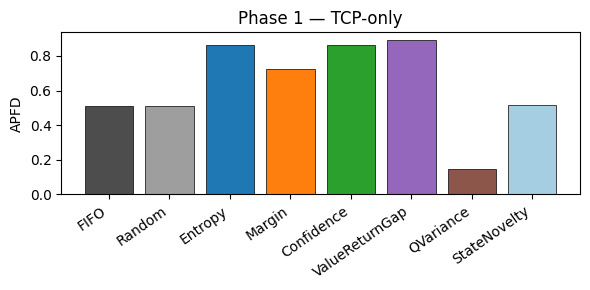

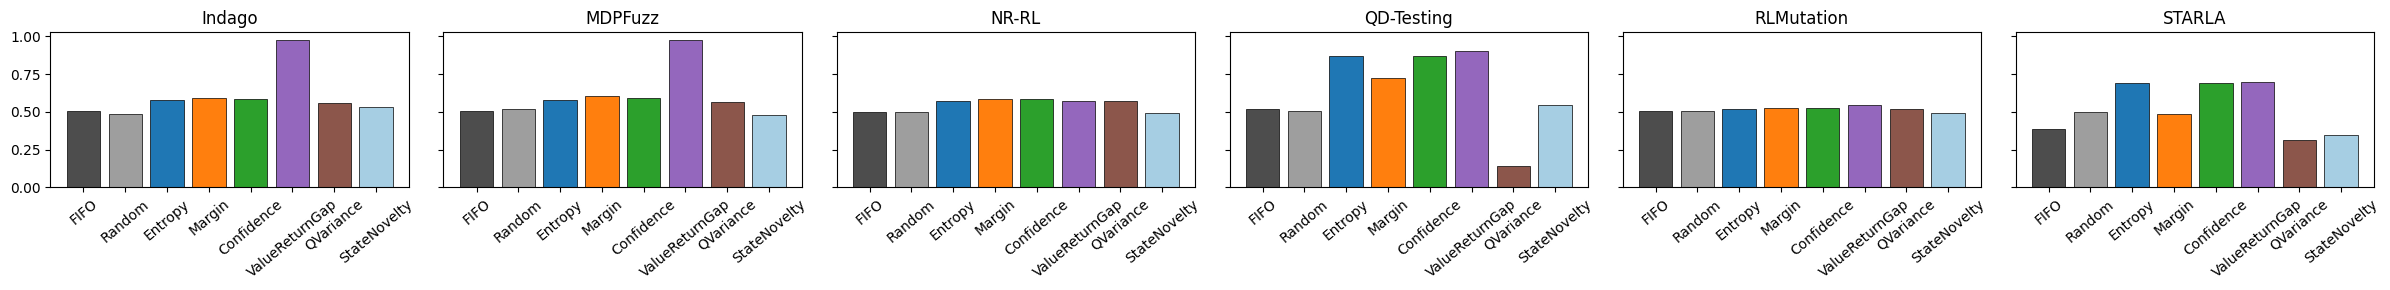

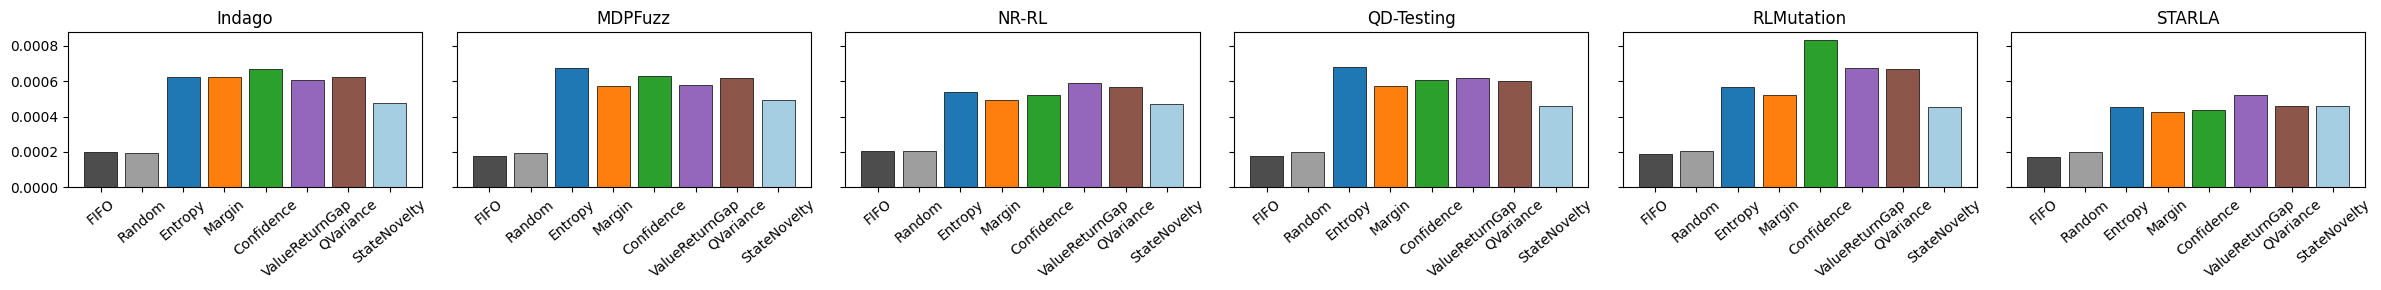


Outputs
Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/taxi/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/taxi/figs


In [98]:
# =============================================================================
# MAIN
# =============================================================================

def main():

    print("=" * 70)
    print("TAXI TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")
    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    print("\nRunning Phase 2...")
    phase2_results = run_phase2()

    phase2_agg = summarize_phase2(
        phase2_results
    )

    phase2_stats = phase2_statistics(
        phase2_results
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print("\nOutputs")

    print(
        f"Tables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {
        "phase1_results": phase1_results,
        "phase1_aggregate": phase1_agg,
        "phase1_statistics": phase1_stats,
        "phase2_results": phase2_results,
        "phase2_aggregate": phase2_agg,
        "phase2_statistics": phase2_stats,
    }


if __name__ == "__main__":

    outputs = main()